### Importing Packages


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
import re

## Data Loading and Inspection


### Observations

##### I have noticed that there are four properties that has 0 Bedrooms, but only one of them is a studio type, and the description for all of them mentions that there are bedrooms, so maybe I will fix that manually
##### I need to check the distribution of area, Bedrooms to check for outliers.
##### There are two properties has a sale price of 1 which does not make sense, and they seems to be an outliers


In [86]:
# Loading the Dataset
df = pd.read_csv(r'../data/apartments.csv')

# Adding a unique identifier for each apartment 
df['apartment_id'] = np.arange(1,len(df)+1)

# Data overview and inspection
print(f'The first few rows of the Dataset:')
display(df.head())

print('Dataset Information:')
df.info()
print(f'The data frame has {df.shape[0]} rows, and {df.shape[1]} columns.')

print('Summary Statistics:')
display(df.describe(include=np.number))

print('Missing Values per column:')
display(df.isnull().sum().sort_values(ascending=False))

print("Duplicated Rows:")
display(df.duplicated().sum())



The first few rows of the Dataset:


,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Price_monthly,Price_annualy,Sale_price,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id
0,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,3.0,3.0,182.0,NaN,NaN,NaN,0,0,طابق أول,Normal,"دير غبار, عمان, الأردن",3 غرف نوم (1 ماستر) - 3 حمامات - صالون - غرفة ...,مطبخ راكب - ارضيات بورسلان - تكييف وحدات - تدف...,1
1,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,4.0,7.0,411.0,NaN,80000.0,NaN,1,0,طابق أرضي,Full Floor,"الرابية, عمان, الأردن",4 غرف نوم ماستر - 7 حمامات - صالون - غرفة معيش...,مسبح خاص - ارضيات بورسلان + باركيه - تكييف مرك...,2
2,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,3.0,3.0,200.0,NaN,NaN,NaN,0,0,طابق أول,Normal,"الدوار السابع, عمان, الأردن",3 غرف نوم (ماستر1) - 3 حمامات - غرفة معيشة - ص...,ارضيات رخام + سيراميك + باركيه - تكييف وحدات -...,3
3,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,120.0,NaN,18000.0,NaN,1,0,تسوية أولى,Normal,"عبدون, عمان, الأردن",2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - 3 ب...,ارضيات بورسلان - تكييف مركزي - مطبخ راكب - خزا...,4
4,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,1.0,63.0,NaN,9000.0,NaN,1,0,طابق أول,Normal,"ام اذينة, عمان, الأردن",غرفة نوم عدد 2 - حمام - غرفة معيشه - مطبخ - مخ...,"السعر: 9,000 دينار اردني سنوي",5


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Listing_type   770 non-null    str    
 1   URL            770 non-null    str    
 2   Bedrooms       769 non-null    float64
 3   Bathrooms      752 non-null    float64
 4   Area_sqm       769 non-null    float64
 5   Price_monthly  10 non-null     float64
 6   Price_annualy  149 non-null    float64
 7   Sale_price     543 non-null    float64
 8   Furnished      770 non-null    int64  
 9   Pool           770 non-null    int64  
 10  Floor          716 non-null    str    
 11  Floor_type     724 non-null    str    
 12  Location       769 non-null    str    
 13  Description    735 non-null    str    
 14  Specialities   717 non-null    str    
 15  apartment_id   770 non-null    int64  
dtypes: float64(6), int64(3), str(7)
memory usage: 96.4 KB
The data frame has 770 rows, and 1

,Bedrooms,Bathrooms,Area_sqm,Price_monthly,Price_annualy,Sale_price,Furnished,Pool,apartment_id
count,769.000000,752.000000,769.000000,10.000000,149.000000,543.000000,770.000000,770.000000,770.000000
mean,3.161248,3.738032,223.880364,8815.000000,16495.973154,237239.915285,0.251948,0.088312,385.500000
std,0.800395,1.170767,85.653713,5122.719005,10038.472474,130767.825595,0.434414,0.283932,222.424144
min,0.000000,1.000000,44.000000,750.000000,4200.000000,1.000000,0.000000,0.000000,1.000000
25%,3.000000,3.000000,175.000000,6475.000000,10000.000000,161000.000000,0.000000,0.000000,193.250000
50%,3.000000,4.000000,212.000000,9500.000000,14000.000000,220000.000000,0.000000,0.000000,385.500000
75%,4.000000,4.000000,255.000000,12625.000000,19000.000000,290000.000000,1.000000,0.000000,577.750000
max,8.000000,8.000000,822.000000,15000.000000,80000.000000,957000.000000,1.000000,1.000000,770.000000


Missing Values per column:


Price_monthly    760
Price_annualy    621
Sale_price       227
Floor             54
Specialities      53
Floor_type        46
Description       35
Bathrooms         18
Location           1
Bedrooms           1
Area_sqm           1
Listing_type       0
URL                0
Pool               0
Furnished          0
apartment_id       0
dtype: int64

Duplicated Rows:


np.int64(0)

In [87]:
# Displaying the apartments that have 0 bedrooms
print('Apartments with 0 bedrooms:\n')
display(df[df['Bedrooms'] == 0])
print('---'*20)

# Displaying the apartments that have the minimum sale price
print('Apartments with the lowest sale price are:\n')
display(df[df['Sale_price'] == df['Sale_price'].min()])
print('---'*20)

Apartments with 0 bedrooms:



,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Price_monthly,Price_annualy,Sale_price,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id
572,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,0.0,1.0,44.0,6000.0,NaN,NaN,1,0,طابق أرضي,Normal,"جبل اللويبدة, عمان, الأردن",غرفة نوم - حمام - غرفة معيشة - مطبخ,مطبخ راكب -ارضيات سيراميك - تكييف وحدات - زجاج...,573
628,sale,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,0.0,2.0,81.0,NaN,NaN,52000.0,1,0,طابق ثاني,Studio,"ربوة عبدون, عمان, الأردن",غرفة نوم ماستر - 2 حمامات ndash; صالون - مطبخ ...,"السعر: 52,000 دينار اردني",629
644,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,0.0,1.0,70.0,NaN,18000.0,NaN,1,1,طابق أول,Normal,"العبدلي, عمان, الأردن",غرف نوم ماستر - حمام - معيشة - مطبخ ndash; بلك...,"السعر: 18,000 دينار اردني سنوي",645
684,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,0.0,1.0,70.0,NaN,11000.0,NaN,1,1,طابق رابع,Normal,"العبدلي, عمان, الأردن",غرف نوم ماستر - حمام - معيشة - مطبخ - 2 بلكونة...,"السعر: 11,000 دينار اردني سنوي",685


------------------------------------------------------------
Apartments with the lowest sale price are:



,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Price_monthly,Price_annualy,Sale_price,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id
31,sale,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,3.0,3.0,185.0,NaN,NaN,1.0,0,0,روف,Full Floor,"رجم عميش, عمان, الأردن",غرف نوم عدد 3 (ماستر 1) - حمامات عدد 3 - صالون...,ارضيات بورسلات - وحدات تكييف - تدفئة على الغاز...,32
234,sale,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,4.0,5.0,370.0,NaN,NaN,1.0,0,0,طابق أول,Normal,"كوريدور عبدون, عمان, الأردن",غرف نوم عدد 4 (3 ماستر) - حمامات عدد 5 - صالون...,*يتم التسليم في شهر 1 *ملاحظة: صورة الاعلان تع...,235


------------------------------------------------------------


# Data Exploration

## Observations:

##### The DataFrame does not contain duplicated values

##### The len() function returns the number of rows in the Dataframe, in a column (pandas Series) including the NaN values.

##### The dtype of Bedrooms and Bathrooms columns is float so they need to be converted to int64 type, as it is not possible that a property has 3.5 bedrooms

##### There are 760 missing values in the Price_monthly column, and 621 missing value in the Price_annualy column, so we need to know exactly how many missing values are there in these columns since we have two listing types (sale,rent), so out of all the rent properties we need to get the total number of missing values of their prices

##### for the sale price column there is around 200 missing value, also here we need to get the missing values of the sale price out of the sale listing type only; because these results are not accurate since the dataset is a mixture of rent and sale so the missing values in the sale price column are not all a missing values for the sale_price column actually and they are missing because the property is not rent and the same thing for rent listing type  

The Dataset contains 770 rows, and 16 columns.
Information about the colunmn: Listing_type
          Data type: str
          Number of missing values in the column: 0
          Proportion of the missing values in the column: 0.00%

Information about the colunmn: URL
          Data type: str
          Number of missing values in the column: 0
          Proportion of the missing values in the column: 0.00%

Information about the colunmn: Bedrooms
          Data type: float64
          Number of missing values in the column: 1
          Proportion of the missing values in the column: 0.13%

Information about the colunmn: Bathrooms
          Data type: float64
          Number of missing values in the column: 18
          Proportion of the missing values in the column: 2.34%

Information about the colunmn: Area_sqm
          Data type: float64
          Number of missing values in the column: 1
          Proportion of the missing values in the column: 0.13%

Information about the colunmn:

C:\Users\User\AppData\Local\Temp\ipykernel_10572\1444729516.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.countplot(data=df,


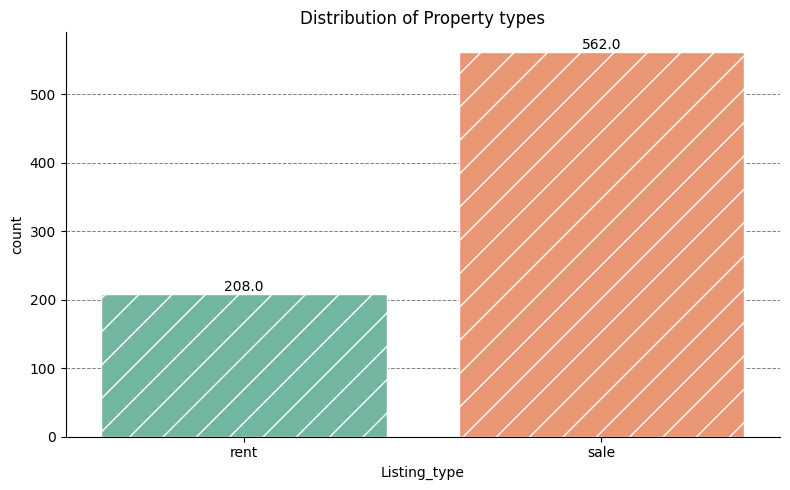

The number of missing values in sale price for sale listings: 19
The number of missing values in monthly, and annualy price for rent listings:
Price_monthly    198
Price_annualy     59
dtype: int64


In [88]:
print(f'The Dataset contains {df.shape[0]} rows, and {df.shape[1]} columns.')

# Extracting the columns names for further analysis
columns = df.columns.to_list()
for col in columns:
    print(f'Information about the colunmn: {col}\n\
          Data type: {df[col].dtype}\n\
          Number of missing values in the column: {df[col].isnull().sum()}\n\
          Proportion of the missing values in the column: {df[col].isnull().sum()/len(df[col])*100:.2f}%\n')
    
# The len() function returns the number of rows in the Dataframe, in a column (pandas Series) 
# including the NaN values.

# Extracting the listing type distibution
print(f'The DataFrame contains {df['Listing_type'].value_counts().loc["sale"]} sale listings,'
      f'and {df['Listing_type'].value_counts().loc["rent"]} rent listings.')

plt.figure(figsize=(8,5))
bars = sns.countplot(data=df,
              x='Listing_type',
              palette='Set2')
for bar in bars.patches:
    y_value = bar.get_height()
    x_val = bar.get_x() + (bar.get_width()/2)
    if y_value > 0:
        plt.text(x_val,y_value,y_value,ha='center',va='bottom')
    bar.set_edgecolor('white')
    bar.set_hatch('/')
sns.despine()
plt.grid(axis='y',
         linestyle='--',
         linewidth=0.7,
         color='gray')
plt.gca().set_axisbelow(True)
plt.title('Distribution of Property types')
plt.tight_layout()
plt.show()
# subset the dataframe to include only the sale listings
print(f'The number of missing values in sale price for sale listings: '
      f'{df[df['Listing_type'] == 'sale']['Sale_price'].isnull().sum()}'
      )

# subset the dataframe to include only the sale listings
print(f'The number of missing values in monthly, and annualy price for rent listings:\n'
      f'{df[df['Listing_type'] == 'rent'][['Price_monthly','Price_annualy']].isnull().sum()}')



## Missing Values Analysis

### Observations

##### after subsetting the data we found that there was only 19 missing values in the sale price column, and 198 in the price_monthly, and 59 in the price_annualy.

##### now I need to solve the issue of the price for rent listings since there are two columns for the price(monthly,annually) so I need to choose one of them 
##### since the price_monthly column has 198 missing values out of 208 values, maybe I will drop the column, or I would impute the missing values in the Price_annualy column and calculate the monthly price from it

##### Note: when imputing and filling the prices columns, I should be aware that it is not correct to impute all the data, and subset for the appropriate listing type before imputation and then proceed with the imputation

In [89]:
print(f'The DataFrame contains {df['Listing_type'].value_counts().loc["sale"]}'
       f' sale listings, and {df['Listing_type'].value_counts().loc["rent"]} rent listings.')

# subset the dataframe to include only the sale listings
print(f'The number of missing values in sale price for sale listings:'
       f' {df[df['Listing_type'] == 'sale']['Sale_price'].isnull().sum()}')

# subset the dataframe to include only the sale listings
print(f'The number of missing values in monthly, and annualy price for rent listings:\n'
      f'{df[df['Listing_type'] == 'rent'][['Price_monthly','Price_annualy']].isnull().sum()}')

The DataFrame contains 562 sale listings, and 208 rent listings.
The number of missing values in sale price for sale listings: 19
The number of missing values in monthly, and annualy price for rent listings:
Price_monthly    198
Price_annualy     59
dtype: int64


### Observations

##### The DataFrame contains six different types of floor types
##### The location column has 36 different locations for the apartments, and the location is written in Arabic in the form of 'country,city,town'
##### The apartments in the DataFrame are distributed among 14 floors 
##### The description and the specialities features are going to be a big challenge as they are paragraphs 

In [90]:
# Separating the categorical and numerical features for analysis

categorical_cols = df.select_dtypes(exclude=np.number).columns.to_list()
numerical_cols = df.select_dtypes(include=np.number).columns.to_list()

print(f'The categorical Columns are:\n{categorical_cols}\n')
print(f'The numerical Columns are:\n{numerical_cols}\n')

# Extracting the unique values for each column
print('The Unique values in some of categorical columns:')
display(df['Floor_type'].unique())
display(df['Listing_type'].unique())
display(df['Furnished'].nunique())
display(df['Location'].head())
display(df['Floor'].unique())
display(df['Location'].unique())


The categorical Columns are:
['Listing_type', 'URL', 'Floor', 'Floor_type', 'Location', 'Description', 'Specialities']

The numerical Columns are:
['Bedrooms', 'Bathrooms', 'Area_sqm', 'Price_monthly', 'Price_annualy', 'Sale_price', 'Furnished', 'Pool', 'apartment_id']

The Unique values in some of categorical columns:


<StringArray>
['Normal', 'Full Floor', 'Duplex', nan, 'Flat', 'Studio']
Length: 6, dtype: str

<StringArray>
['rent', 'sale']
Length: 2, dtype: str

2

0         دير غبار,  عمان,  الأردن
1          الرابية,  عمان,  الأردن
2    الدوار السابع,  عمان,  الأردن
3            عبدون,  عمان,  الأردن
4         ام اذينة,  عمان,  الأردن
Name: Location, dtype: str

<StringArray>
[        'طابق أول',        'طابق أرضي',       'تسوية أولى',
        'طابق ثاني',        'طابق ثالث',              'روف',
                nan, 'طابق أخير مع روف',      'تسوية ثالثة',
    'طابق شبه أرضي',        'طابق سادس',      'تسوية ثانية',
        'طابق رابع',        'طابق خامس']
Length: 14, dtype: str

<StringArray>
[          'دير غبار,  عمان,  الأردن',            'الرابية,  عمان,  الأردن',
      'الدوار السابع,  عمان,  الأردن',              'عبدون,  عمان,  الأردن',
           'ام اذينة,  عمان,  الأردن',      'الدوار الخامس,  عمان,  الأردن',
          'الشميساني,  عمان,  الأردن',  'ضاحية الأمير راشد,  عمان,  الأردن',
      'الدوار الرابع,  عمان,  الأردن',       'جبل اللويبدة,  عمان,  الأردن',
             'الظهير,  عمان,  الأردن',             'الفحيص,  عمان,  الأردن',
        'قرية النخيل,  عمان,  الأردن',           'جبل عمان,  عمان,  الأردن',
             'صويفية,  عمان,  الأردن',            'العبدلي,  عمان,  الأردن',
         'حي الصحابة,  عمان,  الأردن',           'رجم عميش,  عمان,  الأردن',
              'دابوق,  عمان,  الأردن',             'الكرسي,  عمان,  الأردن',
        'شارع المطار,  عمان,  الأردن',         'مرج الحمام,  عمان,  الأردن',
               'خلدا,  عمان,  الأردن',            'البنيات,  عمان,  الأردن',
              'الحمر,  عمان,  الأردن',         'ربوة عبدون,  ع

In [91]:
display(df['Location'].value_counts().sort_values(ascending=False))
display(df['Specialities'].head(20))

'''df['Location'].iloc[10].strip(' ').split(',')
for row in df['Location']:
    if isinstance(row,str):
        location_parts = row.strip(' ').split(',')
    print(location_parts[0])
    df['City'] = location_parts[1]
    df['Town'] = location_parts[2]
df.head()
'''

df['Description'].head()

Location
دير غبار,  عمان,  الأردن              82
دابوق,  عمان,  الأردن                 74
عبدون,  عمان,  الأردن                 73
قرية النخيل,  عمان,  الأردن           66
شارع المطار,  عمان,  الأردن           47
رجم عميش,  عمان,  الأردن              43
الظهير,  عمان,  الأردن                42
خلدا,  عمان,  الأردن                  32
حي الصحابة,  عمان,  الأردن            31
الدوار الرابع,  عمان,  الأردن         27
الكرسي,  عمان,  الأردن                26
مرج الحمام,  عمان,  الأردن            24
ام اذينة,  عمان,  الأردن              22
حجار النوابلسة,  عمان,  الأردن        22
الحمر,  عمان,  الأردن                 18
العبدلي,  عمان,  الأردن               16
ضاحية الأمير راشد,  عمان,  الأردن     15
صويفية,  عمان,  الأردن                14
ام السماق,  عمان,  الأردن             13
الدوار السابع,  عمان,  الأردن         11
جبل عمان,  عمان,  الأردن              11
الرابية,  عمان,  الأردن               10
كوريدور عبدون,  عمان,  الأردن          9
البنيات,  عمان,  الأردن                8
الدوار 

0     مطبخ راكب - ارضيات بورسلان - تكييف وحدات - تدف...
1     مسبح خاص - ارضيات بورسلان + باركيه - تكييف مرك...
2     ارضيات رخام + سيراميك + باركيه - تكييف وحدات -...
3     ارضيات بورسلان - تكييف مركزي - مطبخ راكب - خزا...
4                         السعر: 9,000 دينار اردني سنوي
5     مطبخ راكب - ارضيات بورسلان + رخام - تكييف وحدا...
6     مطبخ - ارضيات سيراميك + رخام - تكييف وحدات - ت...
7                          السعر: 7,000 ديناراردني سنوي
8     ارضيات بورسلان - تكييف مركزي - تدفئة مركزية - ...
9                             السعر: 25,000 دينار اردني
10                       السعر: 12,000 دينار اردني سنوي
11    ارضيات بورسلان - وحدات تكييف - تدفئه على الغاز...
12    ارضيات بورسلان - تكييف وحدات عدد 3 - مطبخ راكب...
13    ارضيات رخام - وحدات تكييف - تدفئة - مطبخ راكب ...
14    ارضيات بورسلان - وحدات تكييف - تدفئة تحت البلا...
15                        السعر: 8,000 دينار اردني سنوي
16    ارضيات بورسلان + بورسلان - تكييف مركزي - تدفئة...
17    ارضيات بورسلان - تكييف وحدات - تدفئة على ا

0    3 غرف نوم (1 ماستر) - 3 حمامات - صالون - غرفة ...
1    4 غرف نوم ماستر - 7 حمامات - صالون - غرفة معيش...
2    3 غرف نوم (ماستر1) - 3 حمامات - غرفة معيشة - ص...
3    2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - 3 ب...
4    غرفة نوم عدد 2 - حمام - غرفة معيشه - مطبخ - مخ...
Name: Description, dtype: str

### Observations:

##### After reviewing the distributions of the area and the number of bedrooms, there is no outliers in the data; due to there are more than one floor type in the properties and 

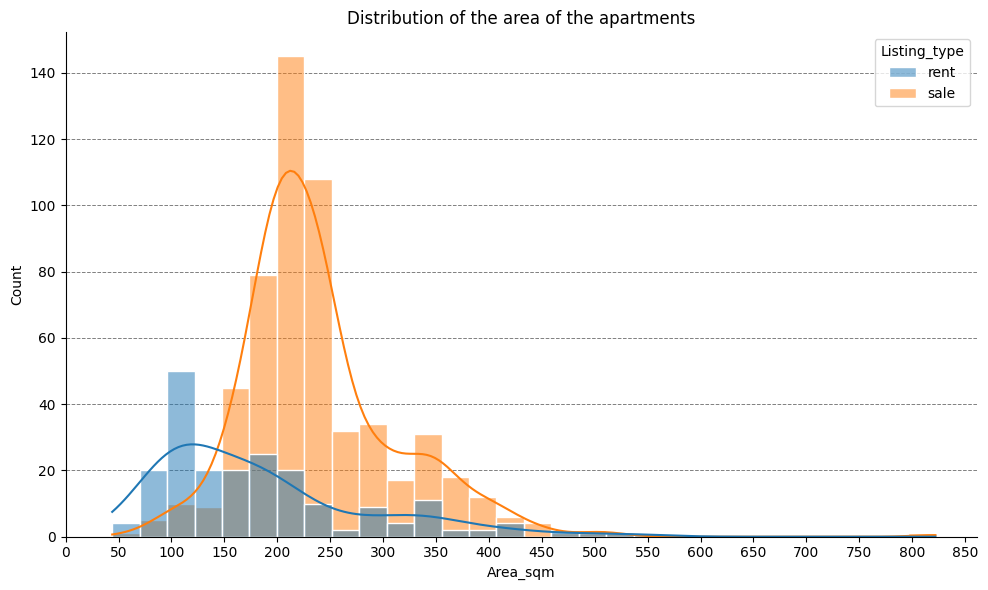

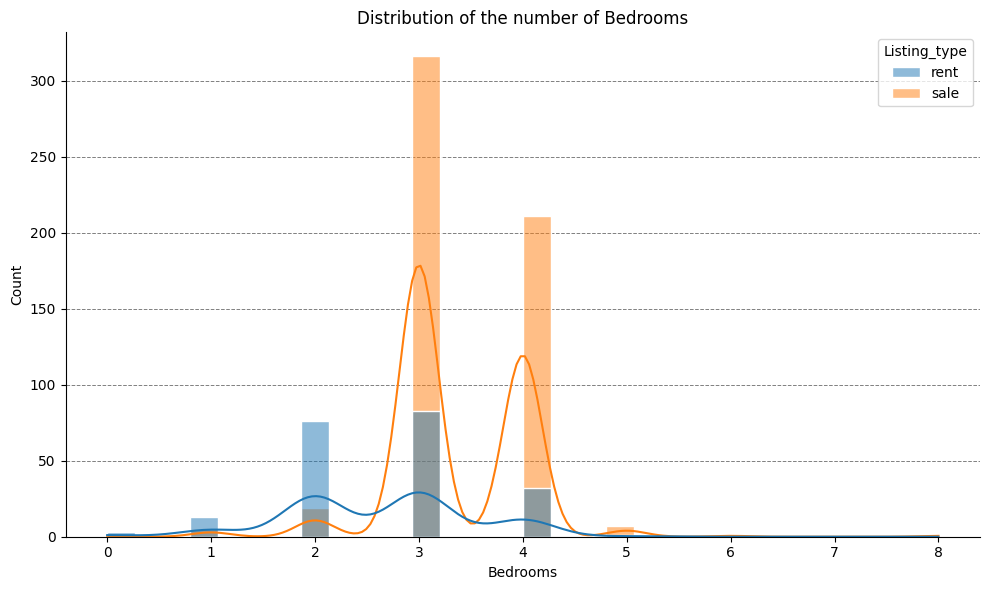

In [92]:
plt.figure(figsize=(10,6),dpi=100)
# Plotting the distribution of the area for the apartments
sns.histplot(data=df,
             x='Area_sqm',
             bins=30,
             kde=True,
             color='skyblue',
             edgecolor='white',
             hue='Listing_type')
sns.despine(right=True,top=True,left=False)
plt.grid(axis='y',linestyle='--',linewidth=0.7,color='gray')
plt.gca().set_axisbelow(True)
plt.title('Distribution of the area of the apartments')
plt.xticks(ticks=np.arange(0,df['Area_sqm'].max()+50,50))
plt.tight_layout()
plt.show()

# Distribution of the number of Bedrooms
plt.figure(figsize=(10,6),dpi=100)
sns.histplot(data=df,
             x='Bedrooms',
             bins=30,
             kde=True,
             color='salmon',
             edgecolor='white',
             hue='Listing_type')
sns.despine()
plt.grid(axis='y',linestyle='--',linewidth=0.7,color='gray')
plt.gca().set_axisbelow(True)
plt.title('Distribution of the number of Bedrooms')
plt.tight_layout()
plt.show()


In [93]:
df[df['Area_sqm'].isin([df['Area_sqm'].min(), df['Area_sqm'].max()])]
df['Floor_type'].value_counts().sort_values(ascending=False)

Floor_type
Normal        527
Full Floor     99
Duplex         94
Flat            2
Studio          2
Name: count, dtype: int64

## Data Cleaning Plan

##### - Drop unnecessary columns such as URL column
##### - Convert Bedrooms, and Bathrooms columns to Int64 data type instead of float
##### - Handle missing values for the price columns(Price_monthly,Price_annually,Sale_price)
##### - Since the Price_monthly column contains 198 missing values, I will impute the missing values in the Price_annually column and compute the Price_monthly from it 
##### - The data contains two observations with sale price of 1 which does not make sense, so I will drop those observations, I will impute the values based on the mean value of properties similar to them
##### - The specialities feature contains 53 missing values, and the description column contains 35 missing values and these values will be replaced by 'Unkown'
##### - for the most of the missing values in the categorical features they will be imputed by the most frequent value in the column
##### - for the missing values in the Bathrooms column, I will fill the missing values with the median of Bathrooms for each group of bedrooms, or I can extract the number from the specialities or description columns, as well as for the Bedrooms, Floor_type, Bedrooms, Location, area_sqm and Floor features but I will left it for an advanced stage

In [94]:
df['Sale_price'].min()
df[df['Sale_price'] == df['Sale_price'].min()]

df.groupby('Bedrooms')['Bathrooms'].median()

Bedrooms
0.0    1.0
1.0    1.0
2.0    2.0
3.0    3.0
4.0    5.0
5.0    6.0
6.0    6.0
8.0    7.0
Name: Bathrooms, dtype: float64

### Experimental Feature recovery:
##### I want to test if I can extract the missing values for some features from the specialities and the description columns if applicable, so I want to examine if those values are available for the missing values of rows from the Bathrooms, Bedrooms, and prices columns

In [95]:
# subsetting the DataFrame to include only the observations where the Bathrooms is null
print('Apartments with missing values in the Bathrooms column:\n')
display(df[df['Bathrooms'].isna()][['Specialities','Description']])

# subsetting the DataFrame to include only the observations where the Bedrooms is null
print('Apartments with missing values in the Bedrooms column:\n')
display(df[df['Bedrooms'].isna()][['Specialities','Description']])

# subsetting the DataFram to include only the observations where the Price_annually is null
print('Apartments with missing values in the Price_annualy column:\n')
display(df[(df['Price_annualy'].isna()) & (df['Listing_type'] == 'rent')][['Specialities','Description']])

# subsetting the DataFrame to only include the observations where the Sale_price is null
print('Apartments with missing values in the Sale_price column:\n')
display(df[(df['Sale_price'].isna()) & (df['Listing_type'] == 'sale')][['Specialities','Description']])

Apartments with missing values in the Bathrooms column:



,Specialities,Description
33,"السعر: 350,000 دينار اردني",4 غرف نوم (2 ماستر) - 5 حمامات - صالون - غرفة ...
300,NaN,NaN
327,"السعر: 265,000 دينار اردني",غرف نوم ماستر عدد 3 - حمامات عدد 5 ndash; صالو...
328,"السعر: 230,000 دينار اردني",غرف نوم ماستر عدد 3 - حمامات عدد 5 ndash; صالو...
409,NaN,NaN
410,NaN,NaN
427,NaN,NaN
428,NaN,NaN
435,NaN,NaN
436,NaN,NaN


Apartments with missing values in the Bedrooms column:



,Specialities,Description
300,NaN,NaN


Apartments with missing values in the Price_annualy column:



,Specialities,Description
0,مطبخ راكب - ارضيات بورسلان - تكييف وحدات - تدف...,3 غرف نوم (1 ماستر) - 3 حمامات - صالون - غرفة ...
2,ارضيات رخام + سيراميك + باركيه - تكييف وحدات -...,3 غرف نوم (ماستر1) - 3 حمامات - غرفة معيشة - ص...
5,مطبخ راكب - ارضيات بورسلان + رخام - تكييف وحدا...,غرف نوم عدد 3 (1 ماستر) - 3 حمامات - صالون - غ...
6,مطبخ - ارضيات سيراميك + رخام - تكييف وحدات - ت...,3 غرف نوم - 5 حمامات - غرفة معيشة - صالون - مخ...
9,"السعر: 25,000 دينار اردني",4 غرف نوم (2 ماستر ) - 4 حمامات - غرفة معيشه -...
13,ارضيات رخام - وحدات تكييف - تدفئة - مطبخ راكب ...,غرف نوم عدد 3 (ماستر عدد 1) - حمامات عدد 4 - ص...
20,"السعر: 18,000 دينار اردني",غرف نوم عدد 3 ( 1 ماستر ) - حمامات عدد 4 - صال...
27,مسبح مشترك - اثاث - مطبخ راكب - ارضيات سيراميك...,غرف نوم عدد 2 (ماستر 1) - حمامات عدد 2 - صالون...
28,NaN,NaN
412,مسبح مشترك - صالة رياضية - مطبخ راكب - ارضيات ...,غرف نوم عدد 3 (ماستر 1) - حمامات عدد 3 - غرفة ...


Apartments with missing values in the Sale_price column:



,Specialities,Description
54,ارضيات بورسلان - تكييف مركزي - تدفئة تحت البلا...,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 4 - صالون...
99,NaN,NaN
100,NaN,NaN
101,NaN,NaN
102,NaN,NaN
106,NaN,NaN
207,NaN,غرف نوم عدد 4 (ماستر عدد 3) - حمامات عدد 6 nda...
214,NaN,غرف نوم عدد 4 (ماستر عدد 3) - حمامات عدد 6 nda...
283,"السعر: 22,000 دينار اردني سنويا",غرف نوم ماستر عدد4 - حمامات عدد 6 - غرفة معيشة...
286,مطبخ راكب - ارضيات رخام- وحدات تكييف - تدفئة -...,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 3 - صالون...


In [96]:
before = df['Bathrooms'].isna().sum()

# I want to write a function to extract the number of bathrooms from the 
# Description and Specialities columns using regex

def extract_bathrooms_num(text):
    # if the text is null, then we cant search for the number of bathrooms and it will be Null
    if pd.isna(text):
        return None
    
    # check for arabic pattern
    # I will not check for the english pattern because the data is only in Arabic
    match_ar = re.search(r'(\d+)\s*حمامات',text)
    match_ar2 = re.search(r'حمامات\s*عدد\s*(\d+)',text)
    match_ar3 = re.search(r'(\d+)\s*حمام',text)
    
    if match_ar:
        return int(match_ar.group(1))
    elif match_ar2:
        return int(match_ar2.group(1))
    elif match_ar3:
        return int(match_ar3.group(1))
    
    # if no match were found return None
    return None
     
# now I want to write a function to fill the missing values in the Bathrooms column
# I will apply the extract_bathrooms_num function to both the Description and Specialities columns
# But I need to that I will only fill the missing values in the Bathrooms column, not the whole column

def fill_bathrooms_num(row):
    # if the value is not missing, then we will keep it as it is
    if pd.notna(row['Bathrooms']):
        return row['Bathrooms']
    value = extract_bathrooms_num(row['Description'])
    # if the regex didnt find any match in the description column (the regex will return None), then I will try to extract 
    # the number from the Specialities column
    if value is None:
        value = extract_bathrooms_num(row['Specialities'])
    return value

# now I will apply the fill_bathrooms_num function to the DataFrame where the number 
# of bathrooms is null

df.loc[df['Bathrooms'].isna(),'Bathrooms'] = df.loc[df['Bathrooms'].isna(),:].apply(fill_bathrooms_num,axis=1)

print(f'Filled {before - df["Bathrooms"].isna().sum()} missing values from the Bathrooms column')
print(f'Missing before {before}')
print(f'Missing after {df["Bathrooms"].isna().sum()}')


Filled 11 missing values from the Bathrooms column
Missing before 18
Missing after 7


In [97]:
before = df[df['Listing_type'] == 'rent']['Price_annualy'].isna().sum()

# Annualy price for rent listing types extraction 
def extract_annualy_price(text):
    if pd.isna(text):
        return None
    
    # we will check for arabic pattern since the DataFrame is in arabic
    patterns = [
        r"السعر\s*\(?سنوي(?:ا|اً)?\)?\s*[:\-]?\s*([\d,]+)",
        r"سنوي(?:ا|اً)?\s*[:\-]?\s*([\d,]+)",
        r"([\d,]+)\s*دينار(?:\s*اردني)?\s*(?:سنوي|سنويا|سنوياً)",
        r"السعر\s*[:\-]?\s*([\d,]+)",
    ]
    for pattern in patterns:
        match_ar = re.search(pattern, text)
        if match_ar:
            return int(match_ar.group(1).replace(',',''))
    return None

def fill_annually_price(row):
    if pd.notna(row['Price_annualy']):
        return row['Price_annualy']
    
    # Trying to extract the value from the specialities column first
    value = extract_annualy_price(row['Specialities'])
    if value is None:
        value = extract_annualy_price(row['Description'])
    return value

#df.loc[df['Price_annualy'].isna(),'Price_annualy'] = df.loc[df['Price_annualy'].isna(),:]\
#.apply(fill_annually_price,axis=1)

# making sure to only fill the missing values of the Price_annualy column for the rent listing type
rent_mask = (df['Listing_type'] == 'rent') & (df['Price_annualy'].isna())
#df[df['Listing_type'] == 'rent'].loc[df['Price_annualy'].isna(),'Price_annualy'] =\
#df[df['Listing_type'] == 'rent'].loc[df['Price_annualy'].isna(),:].apply(fill_annually_price,axis=1)
df.loc[rent_mask,'Price_annualy'] = df.loc[rent_mask,:].apply(fill_annually_price,axis=1)


print(f'Filled {before - df[df["Listing_type"] == "rent"]["Price_annualy"].isna().sum()} values')
print(f'Missing before {before}')
print(f'Missing after {df[df["Listing_type"] == "rent"]["Price_annualy"].isna().sum()}')



        

Filled 21 values
Missing before 59
Missing after 38


In [98]:
# Checking for the number of invalid prices in the sale and rent listing types
display(df[(df['Listing_type'] == 'sale') & (df['Sale_price'] <= 1000)].shape[0])
display(df[(df['Listing_type'] == 'rent') & (df['Price_annualy'] <= 1000)].shape[0])

25

0

In [99]:
# Checking for the details of the apartments that have invalid prices 
display(df[df['Sale_price'] <= 1000][['Description','Specialities']])
display(df.loc[df['Sale_price'] <= 1000,['Sale_price','Specialities']])


,Description,Specialities
31,غرف نوم عدد 3 (ماستر 1) - حمامات عدد 3 - صالون...,ارضيات بورسلات - وحدات تكييف - تدفئة على الغاز...
166,غرف نوم عدد 3 ( 1 ماستر) - حمامات عدد 3 - صالو...,ارضيات بورسلان - تكييف مركزي + وحدات - تدفئة ت...
168,غرف نوم عدد 3 ( 1 ماستر) - حمامات عدد 3 - صالو...,ارضيات بورسلان - تكييف مركزي + وحدات - تدفئة ت...
183,غرف نوم عدد 4 (2 ماستر) - حمامات عدد 4 - صالون...,*ملاحظة: صورة الاعلان تعبيرية *يتم التسليم في ...
234,غرف نوم عدد 4 (3 ماستر) - حمامات عدد 5 - صالون...,*يتم التسليم في شهر 1 *ملاحظة: صورة الاعلان تع...
270,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 3 - صالون...,ارضيات بورسلان + رخام - وحدات تكييف - تدفئه تح...
271,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 3 - صالون...,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...
273,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 3 - صالون...,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...
274,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 4 - صالون...,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...
275,غرف نوم عدد 4 (2 ماستر) - حمامات عدد 5 - صالون...,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...


,Sale_price,Specialities
31,1.0,ارضيات بورسلات - وحدات تكييف - تدفئة على الغاز...
166,8.0,ارضيات بورسلان - تكييف مركزي + وحدات - تدفئة ت...
168,8.0,ارضيات بورسلان - تكييف مركزي + وحدات - تدفئة ت...
183,7.0,*ملاحظة: صورة الاعلان تعبيرية *يتم التسليم في ...
234,1.0,*يتم التسليم في شهر 1 *ملاحظة: صورة الاعلان تع...
270,2.0,ارضيات بورسلان + رخام - وحدات تكييف - تدفئه تح...
271,2.0,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...
273,2.0,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...
274,2.0,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...
275,2.0,ارضيات بورسلان - وحدات تكييف - تدفئه تحت البلا...


##### There is an issue in 25 rows in the sale price column for sale listing type, that the prices are invalid and they are less than 100 so we need to try to extract the prices for these invalid observations from the description or the specialities column 

In [100]:
# Now I am going to try to extract the sale price from the description or specialities columns
# for the missing values of the Sale_price column and the invalid values that are less than 1000
#  for the sale listing type

def extract_sale_price(text):
    if pd.isna(text):
        return None
    
    # we will only be checking for an arabic pattern since the data is only in arabic
    patterns = [
        r"السعر\s*[:\-]?\s*([\d,]+)",
        r"سعر\s*\(?البيع\)?\s*[:\-]?\s*([\d,]+)"
    ]

    for pattern in patterns:
        match = re.search(pattern=pattern,string=text)
        if match:
            return int(match.group(1).replace(',',''))
    return None

def fill_sale_price(row): # function for filling the missing values in the sale price column, where the listing type is sale
    if pd.notna(row['Sale_price']):
        return row['Sale_price']
    
    value = extract_sale_price(row['Description'])
    if value is None:
        value = extract_sale_price(row['Specialities'])
    return value

before_missing = df[df['Listing_type'] == 'sale']['Sale_price'].isna().sum() 
before_invalid = df[(df['Listing_type'] == 'sale') & (df['Sale_price'] <= 1000)]['Sale_price'].count
# missing values before filling
# making sure to only fill the missing values of the Sale_price column for& the sale listing type
sale_mask = (df['Listing_type'] == 'sale') & (df['Sale_price'].isna())
df.loc[sale_mask,'Sale_price'] = df.loc[sale_mask,:].apply(fill_sale_price,axis=1)

print(f'Filled {before - (df[df['Listing_type'] == 'sale']['Sale_price'].isna().sum())}' 
      f' missing values from the Sale_price column')
print(f'Missing values in Sale_price column before filling: {before}')
print(f'Missing values in the Sale_price column after filling:'
      f'{df[df['Listing_type'] == 'sale']['Sale_price'].isna().sum()}')


Filled 44 missing values from the Sale_price column
Missing values in Sale_price column before filling: 59
Missing values in the Sale_price column after filling:15


In [101]:

def extract_price(text):
    if pd.isna(text):
        return None
    
    patterns = [
        r"السعر\s*[:\-]?\s*([\d,]+)",
        r"سعر\s*\(?البيع\)?\s*[:\-]?\s*([\d,]+)"
    ]

    for pattern in patterns:
        match = re.search(pattern=pattern,string=text)
        if match:
            return int(match.group(1).replace(',',''))
    return None

def fill_price(row): 
    # function for filling the missing values in the sale price column, where the listing type is sale
    if (pd.notna(row['Sale_price'])) and (row['Sale_price'] > 1000):
        return row['Sale_price']
    
    value = extract_price(row['Description'])
    if value is None:
        value = extract_price(row['Specialities'])
    return  row['Sale_price'] if value is None else value

before = df[(df['Listing_type'] == 'sale') & (df['Sale_price'] <= 1000)]
mask = (df['Listing_type'] == 'sale') & (df['Sale_price'] <= 1000)
df.loc[mask,'Sale_price'] = df.loc[mask,:].apply(fill_price,axis=1)
print(f'extracted price for {before.shape[0] - (df[(df['Listing_type'] == 'sale') & (df['Sale_price'] <= 1000)].shape[0])} ')
print(f'The invalid values in the sale price column before filling: {before.shape[0]}')
print(f'The invalid values in the sale price column after filling: {df[(df['Listing_type'] == 'sale') & (df['Sale_price'] <= 1000)].shape[0]}')

extracted price for 2 
The invalid values in the sale price column before filling: 25
The invalid values in the sale price column after filling: 23


In [102]:
display(df[df['Bedrooms'] == 0][['Description']])
print(f'The number of invalid values in the Bedrooms column is:'
      f'{df[df['Bedrooms'] == 0].shape[0]}')
print(f'the number of missing values in the Bedrooms column is:'
      f'{df['Bedrooms'].isna().sum()}' )


,Description
572,غرفة نوم - حمام - غرفة معيشة - مطبخ
628,غرفة نوم ماستر - 2 حمامات ndash; صالون - مطبخ ...
644,غرف نوم ماستر - حمام - معيشة - مطبخ ndash; بلك...
684,غرف نوم ماستر - حمام - معيشة - مطبخ - 2 بلكونة...


The number of invalid values in the Bedrooms column is:4
the number of missing values in the Bedrooms column is:1


##### Observations
##### The DataFrame contains four rows with Bedrooms value with zero, so we need to extract the number of bedrooms for those rows from the description or the specialities columns

#### Note I need to fix the extracting bedrooms number function logic

In [103]:
# Extracting the no. of bedrooms
before = df[(df['Bedrooms'] == 0) & (df['Bedrooms'].isna())].shape[0]

def extract_bedrooms_num(text):
    if pd.isna(text):
        return None

    patterns = [
        r'(\d+)\s*غرف\s*نوم',
        r'غرف\s*نوم\s*عدد\s*(\d+)',
        r'(\d+)\s*غرفة\s*نوم',
        r'غرفة\s*نوم\s*عدد\s*(\d+)'
    ]

    
    if pd.notna(text) and re.search(r"غرفة\s*نوم(?:\s*ماستر)?", str(text)):
        return 1

    if pd.notna(text) and re.search(r"غرف\s*نوم\s*ماستر", str(text)):
        return 1

    for pattern in patterns:
        match = re.search(pattern=pattern,string=str(text))
        
        if match:
            return int(match.group(1))
    return None

def fill_bedrooms_num(row):
    if row['Bedrooms'] !=0 and pd.notna(row['Bedrooms']):
        return row['Bedrooms']

    value = extract_bedrooms_num(row['Description'])
    if value is None:
        value = extract_bedrooms_num(row['Specialities'])
    return value if value is not None else np.nan

mask = (df['Bedrooms'] == 0)
df.loc[mask,'Bedrooms'] = df.loc[mask,:].apply(fill_bedrooms_num,axis=1)

print(f'Filled {before - (df[(df['Bedrooms'] == 0) & (df['Bedrooms'].isna())]).shape[0]} missing and invalid values')
print(f'Missing and invalid values before filling: {before}')
print(f'Missing and invalid values after filling: {(df[(df['Bedrooms'] == 0) & (df['Bedrooms'].isna())]).shape[0]}')


display(df[df['Bedrooms'] == 0])
df[df['Bedrooms'].isna()]

Filled 0 missing and invalid values
Missing and invalid values before filling: 0
Missing and invalid values after filling: 0


,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Price_monthly,Price_annualy,Sale_price,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id


,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Price_monthly,Price_annualy,Sale_price,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id
300,sale,https://www.homes-jordan.com,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,301


##### Observations from feature extraction 
##### for the Bathrooms missing values, there were 11 values extracted and the remaining missing values in the Bathrooms column is 7
##### for the Price_annualy column, there were 21 values extracted and the remaining missing values in the Price_annualy column for rent listing types are 38 values
##### for the Sale_price column, there were 4 values extracted and the remaining missing values in the Sale_price column for the sale listing type are 15 values
##### out of 25 invalid prices in the Sale_price column for the sale listing type, 2 values were extracted, and the unrecovered values will be turned into NaNs 


### Observations and Notes
##### some of the values missing values from the Batrooms, annualy_price, and Sale_price columns have been recovered and the number of missing values in these columns has been reduced, so:
#### 1- I wiil apply the feature recovery approach before handling the missing values
#### 2- The missing values will be handled as follows:
#####  - The missing values in the bathrooms column will be filled based on the median bathrooms for bedrooms number
#####  - Missing values in the Bedrooms column will be filled with the median of Bedrooms
#####  - Missing values in the Area_sqm column will be filled with the median area
#####  - Missing values in the floor and floor type columns will be filled with unknown 
#####  - Missing values in the description and specialities will be filled with whitespaces
#####  - Missing values in the sale price and the price annualy columns will be dropped  


In [104]:
df.isna().sum().sort_values(ascending=False)

for col in df.columns:
    if col not in ['Price_monthly','Price_annualy','Sale_price']:
        print(f'Missing values in the {col} column: is {df[col].isna().sum()}')

display('The missing values in the Sale_price column for sale listings are:',df[df['Listing_type'] == 'sale']['Sale_price'].isna().sum())
display('The missing values in the Price_annualy column for rent listings are:',df[df['Listing_type'] == 'rent']['Price_annualy'].isna().sum())

Missing values in the Listing_type column: is 0
Missing values in the URL column: is 0
Missing values in the Bedrooms column: is 1
Missing values in the Bathrooms column: is 7
Missing values in the Area_sqm column: is 1
Missing values in the Furnished column: is 0
Missing values in the Pool column: is 0
Missing values in the Floor column: is 54
Missing values in the Floor_type column: is 46
Missing values in the Location column: is 1
Missing values in the Description column: is 35
Missing values in the Specialities column: is 53
Missing values in the apartment_id column: is 0


'The missing values in the Sale_price column for sale listings are:'

np.int64(15)

'The missing values in the Price_annualy column for rent listings are:'

np.int64(38)

In [105]:
df[(df['Listing_type'] == 'sale') & (df['Sale_price'].isna())][['Description','Specialities']]

,Description,Specialities
54,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 4 - صالون...,ارضيات بورسلان - تكييف مركزي - تدفئة تحت البلا...
99,NaN,NaN
100,NaN,NaN
101,NaN,NaN
102,NaN,NaN
106,NaN,NaN
207,غرف نوم عدد 4 (ماستر عدد 3) - حمامات عدد 6 nda...,NaN
214,غرف نوم عدد 4 (ماستر عدد 3) - حمامات عدد 6 nda...,NaN
286,غرف نوم عدد 3 (1 ماستر) - حمامات عدد 3 - صالون...,مطبخ راكب - ارضيات رخام- وحدات تكييف - تدفئة -...
300,NaN,NaN


In [106]:
df['Bathrooms'].isna().sum()
df.groupby('Bedrooms')['Bathrooms'].median()
df.groupby('Bedrooms')['Bathrooms'].transform(lambda x: x.fillna(x.median()))
display(df.columns)

Index(['Listing_type', 'URL', 'Bedrooms', 'Bathrooms', 'Area_sqm',
       'Price_monthly', 'Price_annualy', 'Sale_price', 'Furnished', 'Pool',
       'Floor', 'Floor_type', 'Location', 'Description', 'Specialities',
       'apartment_id'],
      dtype='str')

In [107]:
df[['Description','Specialities']] = df[['Description','Specialities']].fillna('')
df[['Floor_type','Floor']] = df[['Floor_type','Floor']].fillna('Unknown')
df['Area_sqm'] = df['Area_sqm'].fillna(df['Area_sqm'].median())
df['final_price'] = np.where(df['Listing_type'] == 'sale',df['Sale_price'],df['Price_annualy'])
df.dropna(subset=['final_price','Location'],inplace=True,axis=0)
df.drop(columns=['Price_monthly','Price_annualy','Sale_price'],inplace=True,errors='ignore')

df['Bathrooms'].astype(dtype='Int64')
df['Bedrooms'].astype(dtype='Int64')
df['Area_sqm'].astype(dtype='float64')
df['final_price'].astype(dtype='float64')




1      80000.0
3      18000.0
4       9000.0
7       7000.0
8       9000.0
        ...   
765    27000.0
766    35000.0
767    23000.0
768    38000.0
769    19000.0
Name: final_price, Length: 717, dtype: float64

In [108]:
df.shape
df.isna().sum()

Listing_type    0
URL             0
Bedrooms        0
Bathrooms       6
Area_sqm        0
Furnished       0
Pool            0
Floor           0
Floor_type      0
Location        0
Description     0
Specialities    0
apartment_id    0
final_price     0
dtype: int64

In [109]:
#df[df['Price_annualy'] < 1000]

### Feature engineering phase

##### for the floor column, the floors are mentioned as an objects, so I need to use mapping to them to the appropriate floor number
##### I can extract the city and the town from the location column using the string methods and apply it to the whole column
##### Feature extraction from the specialities column


In [110]:
display(df.head())
# Now I need to create a new columns from the location column that contains the city and the area

display(df['Location'].head())

display(df.iloc[5]['Location'].strip(' ').split(',')[1])
df['Area'] = pd.NA
df['City'] = pd.NA

# Extracting the area and the city column by iterating over the location column
'''
for idx,val in df['Location'].items():
    if pd.isna(val):
        continue
    location_parts = [p.strip() for p in (val).split(',')]
    df.at[idx,'Area'] = location_parts[0] if len(location_parts) > 0 else pd.NA
    df.at[idx,'City'] = location_parts[1] if len(location_parts) > 1 else pd.NA
'''
# Using vectorization to extract area and city faster

df[['Area','City','Country']] = df['Location'].str.split(',',expand=True,n=2)
df['Area'] = df['Area'].str.strip()
df['City'] = df['City'].str.strip()
df['Country'] = df['Country'].str.strip()

#display(df['Country'].unique())
display(df['City'].unique())
display(df['Area'].unique())
display(df[['Area','City']])

,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id,final_price
1,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,4.0,7.0,411.0,1,0,طابق أرضي,Full Floor,"الرابية, عمان, الأردن",4 غرف نوم ماستر - 7 حمامات - صالون - غرفة معيش...,مسبح خاص - ارضيات بورسلان + باركيه - تكييف مرك...,2,80000.0
3,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,120.0,1,0,تسوية أولى,Normal,"عبدون, عمان, الأردن",2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - 3 ب...,ارضيات بورسلان - تكييف مركزي - مطبخ راكب - خزا...,4,18000.0
4,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,1.0,63.0,1,0,طابق أول,Normal,"ام اذينة, عمان, الأردن",غرفة نوم عدد 2 - حمام - غرفة معيشه - مطبخ - مخ...,"السعر: 9,000 دينار اردني سنوي",5,9000.0
7,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,104.0,1,0,طابق ثاني,Normal,"ضاحية الأمير راشد, عمان, الأردن",2 غرف نوم (1 ماستر) - 2 حمام - غرفة معيشه - مط...,"السعر: 7,000 ديناراردني سنوي",8,7000.0
8,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,97.0,1,0,طابق أول,Normal,"الدوار الرابع, عمان, الأردن",2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - غرف...,ارضيات بورسلان - تكييف مركزي - تدفئة مركزية - ...,9,9000.0


1              الرابية,  عمان,  الأردن
3                عبدون,  عمان,  الأردن
4             ام اذينة,  عمان,  الأردن
7    ضاحية الأمير راشد,  عمان,  الأردن
8        الدوار الرابع,  عمان,  الأردن
Name: Location, dtype: str

'  عمان'

<StringArray>
['عمان', '', 'البحر الميت']
Length: 3, dtype: str

<StringArray>
[          'الرابية',             'عبدون',          'ام اذينة',
 'ضاحية الأمير راشد',     'الدوار الرابع',          'دير غبار',
      'جبل اللويبدة',            'الظهير',            'الفحيص',
       'قرية النخيل',          'جبل عمان',            'صويفية',
           'العبدلي',        'حي الصحابة',          'رجم عميش',
             'دابوق',            'الكرسي',       'شارع المطار',
        'مرج الحمام',           'البنيات',             'الحمر',
              'خلدا',        'ربوة عبدون',    'حجار النوابلسة',
               'بدر',         'ام السماق',        'تلاع العلي',
     'الدوار الخامس',     'كوريدور عبدون',         'الشميساني',
                  '',     'الدوار السابع',       'البحر الميت',
      'الدوار الاول',          'الجندويل']
Length: 35, dtype: str

,Area,City
1,الرابية,عمان
3,عبدون,عمان
4,ام اذينة,عمان
7,ضاحية الأمير راشد,عمان
8,الدوار الرابع,عمان
...,...,...
765,عبدون,عمان
766,عبدون,عمان
767,دير غبار,عمان
768,الظهير,عمان


In [111]:
df['price_per_sqm'] = df['final_price'].div(df['Area_sqm'],fill_value=np.nan)
df.head()

,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id,final_price,Area,City,Country,price_per_sqm
1,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,4.0,7.0,411.0,1,0,طابق أرضي,Full Floor,"الرابية, عمان, الأردن",4 غرف نوم ماستر - 7 حمامات - صالون - غرفة معيش...,مسبح خاص - ارضيات بورسلان + باركيه - تكييف مرك...,2,80000.0,الرابية,عمان,الأردن,194.647202
3,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,120.0,1,0,تسوية أولى,Normal,"عبدون, عمان, الأردن",2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - 3 ب...,ارضيات بورسلان - تكييف مركزي - مطبخ راكب - خزا...,4,18000.0,عبدون,عمان,الأردن,150.000000
4,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,1.0,63.0,1,0,طابق أول,Normal,"ام اذينة, عمان, الأردن",غرفة نوم عدد 2 - حمام - غرفة معيشه - مطبخ - مخ...,"السعر: 9,000 دينار اردني سنوي",5,9000.0,ام اذينة,عمان,الأردن,142.857143
7,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,104.0,1,0,طابق ثاني,Normal,"ضاحية الأمير راشد, عمان, الأردن",2 غرف نوم (1 ماستر) - 2 حمام - غرفة معيشه - مط...,"السعر: 7,000 ديناراردني سنوي",8,7000.0,ضاحية الأمير راشد,عمان,الأردن,67.307692
8,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,97.0,1,0,طابق أول,Normal,"الدوار الرابع, عمان, الأردن",2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - غرف...,ارضيات بورسلان - تكييف مركزي - تدفئة مركزية - ...,9,9000.0,الدوار الرابع,عمان,الأردن,92.783505


In [112]:
'''for i in range(len(df)):
    print(df.iloc[i]['text'])'''

"for i in range(len(df)):\n    print(df.iloc[i]['text'])"

#### Feature Extraction from description and specialities columns
##### I am going to extract the most common important binary features from the text 
##### I have extracted also the number of salons and the masters bedrooms  

In [113]:
def normalize_text(text):
    if pd.isna(text):
        return ''
    return re.sub(r'\s+',' ',str(text)).strip()

df['text'] = (df['Description'] + ' ' + df['Specialities']).apply(normalize_text)
df['has_elevator'] = df['text'].str.contains(r'مصعد').astype(int)
df['has_parking'] = df['text'].str.contains(r'كراج').astype(int)
df['has_storage'] = df['text'].str.contains(r'مخزن').astype(int)
df['has_balcony'] = df['text'].str.contains(r'بلكونة|بلكون|بلكونه',regex=True).astype(int)
df['has_garden'] = df['text'].str.contains(r'حديقة').astype(int)
df['has_gym'] = df['text'].str.contains(r'جيم|صالة\s*رياضية|نادي\s*رياضي',regex=True).astype(int)
df['has_living_room'] = df['text'].str.contains(r'غرفة\s*معيشة|غرفة\s*معيشه',regex=True).astype(int)
df['has_kitchen'] = df['text'].str.contains(r'مطبخ').astype(int)
df['has_laundry_room'] = df['text'].str.contains(r'غرفة غسيل|غرفة\s*غسيل|غسيل').astype(int)
df['has_heating'] = df['text'].str.contains( r'تدفئة|تدفئة\s*مركزية|تدفئة\s*تحت\s*البلاط',regex=True).astype(int)
df['has_AC'] = df['text'].str.contains(r'تكييف|تكييف\s*مركزي|وحدات\s*تكييف',regex=True).astype(int)
df['has_security_doors'] = df['text'].str.contains( r'ابواب\s*امان|أبواب\s*أمان|باب\s*امان|باب\s*أمان',regex=True).astype(int)






C:\Users\User\AppData\Local\Temp\ipykernel_10572\1802698964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.countplot(data=df,


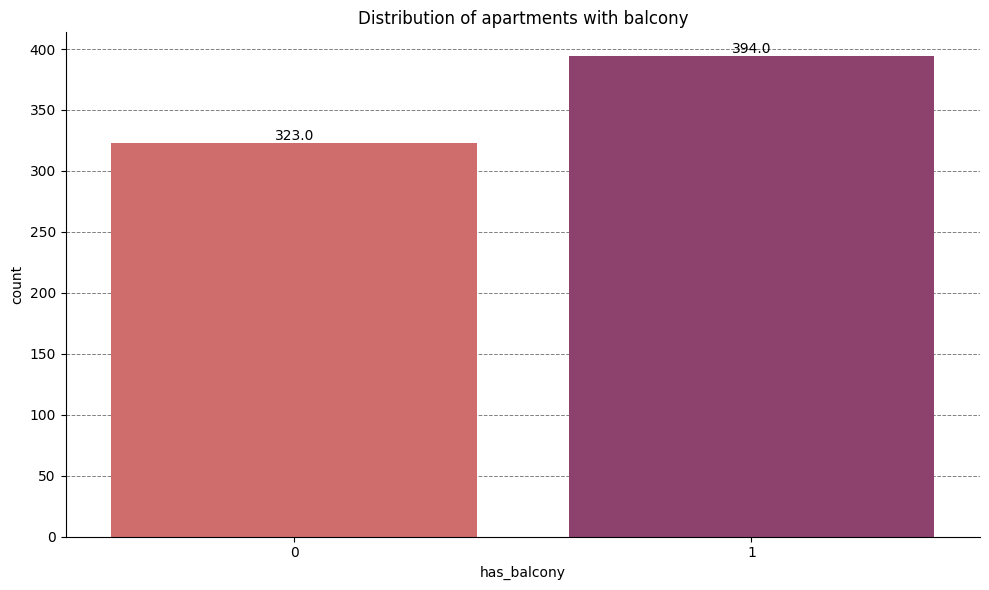

In [114]:
plt.figure(figsize=(10,6),dpi=100)
bars = sns.countplot(data=df,
              x='has_balcony',
              palette='flare')
for bar in bars.patches:
    y_val = bar.get_height()
    x_pos = bar.get_x() + (bar.get_width()/2)
    if y_val > 0:
        plt.text(x_pos,y_val,y_val,ha='center',va='bottom')
sns.despine()
plt.grid(axis='y',linestyle='--',linewidth=0.7,color='gray')
plt.gca().set_axisbelow(True)
plt.title('Distribution of apartments with balcony')
plt.tight_layout()
plt.show()

In [115]:
'''for i in range(len(df['text'])):
    display(df.iloc[i]['text'])'''


df['salon'] = pd.NA

def extract_salons(text):
    if pd.isna(text):
        return 0
    
    patterns = [
        r'(\d+)\s*صالون',
        r'صالون\s*عدد\s*(\d+)'

    ]

    for pattern in patterns:
        match = re.search(pattern,str(text))
        if match:
            return int(match.group(1))
    if re.search(r'\bصالون\b',str(text)):
        return 1
    return 0

def fill_salons(row):
    value = extract_salons(row['text'])
    return value if value is not None else 0

df['salon'] = df.apply(fill_salons,axis=1)

df.head()
df['salon'].value_counts()
df.head()

,Listing_type,URL,Bedrooms,Bathrooms,Area_sqm,Furnished,Pool,Floor,Floor_type,Location,Description,Specialities,apartment_id,final_price,Area,City,Country,price_per_sqm,text,has_elevator,has_parking,has_storage,has_balcony,has_garden,has_gym,has_living_room,has_kitchen,has_laundry_room,has_heating,has_AC,has_security_doors,salon
1,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,4.0,7.0,411.0,1,0,طابق أرضي,Full Floor,"الرابية, عمان, الأردن",4 غرف نوم ماستر - 7 حمامات - صالون - غرفة معيش...,مسبح خاص - ارضيات بورسلان + باركيه - تكييف مرك...,2,80000.0,الرابية,عمان,الأردن,194.647202,4 غرف نوم ماستر - 7 حمامات - صالون - غرفة معيش...,1,1,1,0,1,0,1,1,1,1,1,1,1
3,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,120.0,1,0,تسوية أولى,Normal,"عبدون, عمان, الأردن",2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - 3 ب...,ارضيات بورسلان - تكييف مركزي - مطبخ راكب - خزا...,4,18000.0,عبدون,عمان,الأردن,150.000000,2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - 3 ب...,1,1,0,1,0,0,1,1,0,0,1,0,0
4,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,1.0,63.0,1,0,طابق أول,Normal,"ام اذينة, عمان, الأردن",غرفة نوم عدد 2 - حمام - غرفة معيشه - مطبخ - مخ...,"السعر: 9,000 دينار اردني سنوي",5,9000.0,ام اذينة,عمان,الأردن,142.857143,غرفة نوم عدد 2 - حمام - غرفة معيشه - مطبخ - مخ...,0,1,1,0,0,0,1,1,0,0,0,0,0
7,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,104.0,1,0,طابق ثاني,Normal,"ضاحية الأمير راشد, عمان, الأردن",2 غرف نوم (1 ماستر) - 2 حمام - غرفة معيشه - مط...,"السعر: 7,000 ديناراردني سنوي",8,7000.0,ضاحية الأمير راشد,عمان,الأردن,67.307692,2 غرف نوم (1 ماستر) - 2 حمام - غرفة معيشه - مط...,0,1,1,1,0,0,1,1,0,0,0,0,0
8,rent,https://www.homes-jordan.com/ar/%D9%84%D9%84%D...,2.0,2.0,97.0,1,0,طابق أول,Normal,"الدوار الرابع, عمان, الأردن",2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - غرف...,ارضيات بورسلان - تكييف مركزي - تدفئة مركزية - ...,9,9000.0,الدوار الرابع,عمان,الأردن,92.783505,2 غرف نوم - 2 حمامات - غرفة معيشة - مطبخ - غرف...,1,1,0,0,0,0,1,1,1,1,1,0,0


In [116]:
def extract_master_bedroom(text):
    if pd.isna(text):
        return 0
    patterns = [
        r'ماستر\s*عدد\s*(\d+)',
        r'(\d+)\s*ماستر',
        r'\((\d+)\s*ماستر\)',
        r'\(ماستر\s*(\d+)\)',
        r'\(ماستر\s*عدد\s*(\d+)\)'
    ]

    for pattern in patterns:
        match = re.search(pattern=pattern,
                          string=str(text))
        if match:
            return int(match.group(1))
    if re.search(pattern=r'غرفة\s*نوم\s*ماستر|نوم\s*ماستر',string=str(text)):
        return 1
    return 0

def fill_master_bedroom(row):
    value = extract_master_bedroom(row['text'])
    return value if value is not None else 0
df['master_bedrooms'] = df.apply(fill_master_bedroom,axis=1)

df.head()
df['master_bedrooms'].value_counts()

master_bedrooms
1    369
2    219
0     57
3     37
4     33
5      2
Name: count, dtype: int64

##### I have found that there are 4 observations in the Location column in the dataframe are invalid and the city and the area are not mentioned, so maybe I will fill those observations with the most frequent values for each column

##### I need to check and decide what features I want to extract from the combination of the description and specialities column
##### I want the features that I want to extract to be binary, like holding the value 1 and 0
##### After extracting new features then I will start encoding and standardizing the categorical and numerical features respectively by choosing the appropriate encoding and scaling methods


##### The most important binary features to extract would be parking, balcony, storage, elevator, garden, terrace


##### regarding the salons I did not extract it as a binary feature cause some properties comes with more than one salon

In [117]:
pd.set_option('display.max_columns',None)
df.head()
features = []
for col in df.columns:
    if col not in ['URL','Location','Description','Specialities','Country','text','apartment_id']:
        features.append(col)

print(len(features))     
print(features)
X = df[features].copy()
X.head()


26
['Listing_type', 'Bedrooms', 'Bathrooms', 'Area_sqm', 'Furnished', 'Pool', 'Floor', 'Floor_type', 'final_price', 'Area', 'City', 'price_per_sqm', 'has_elevator', 'has_parking', 'has_storage', 'has_balcony', 'has_garden', 'has_gym', 'has_living_room', 'has_kitchen', 'has_laundry_room', 'has_heating', 'has_AC', 'has_security_doors', 'salon', 'master_bedrooms']


,Listing_type,Bedrooms,Bathrooms,Area_sqm,Furnished,Pool,Floor,Floor_type,final_price,Area,City,price_per_sqm,has_elevator,has_parking,has_storage,has_balcony,has_garden,has_gym,has_living_room,has_kitchen,has_laundry_room,has_heating,has_AC,has_security_doors,salon,master_bedrooms
1,rent,4.0,7.0,411.0,1,0,طابق أرضي,Full Floor,80000.0,الرابية,عمان,194.647202,1,1,1,0,1,0,1,1,1,1,1,1,1,1
3,rent,2.0,2.0,120.0,1,0,تسوية أولى,Normal,18000.0,عبدون,عمان,150.000000,1,1,0,1,0,0,1,1,0,0,1,0,0,0
4,rent,2.0,1.0,63.0,1,0,طابق أول,Normal,9000.0,ام اذينة,عمان,142.857143,0,1,1,0,0,0,1,1,0,0,0,0,0,0
7,rent,2.0,2.0,104.0,1,0,طابق ثاني,Normal,7000.0,ضاحية الأمير راشد,عمان,67.307692,0,1,1,1,0,0,1,1,0,0,0,0,0,1
8,rent,2.0,2.0,97.0,1,0,طابق أول,Normal,9000.0,الدوار الرابع,عمان,92.783505,1,1,0,0,0,0,1,1,1,1,1,0,0,0


In [118]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
numerical_cols = X.select_dtypes(include=np.number).columns.to_list()
categorical_cols = X.select_dtypes(exclude=np.number).columns.to_list()
binary_cols = [col for col in numerical_cols if X[col].nunique() == 2]
non_binary_numeric_cols = [col for col in numerical_cols if col not in binary_cols]



print(f'The numerical columns are:\n{numerical_cols}\n')
print(f'The categorical columns are:\n{categorical_cols}\n')
print(f'The binary columns are:\n{binary_cols}\n')
print(f'The non-binary numerical columns are:\n{non_binary_numeric_cols}\n')
for col in numerical_cols:
    display(X[col].unique())


X_scaled = X.copy()

# scaling the non-binary numerical features
X_scaled[non_binary_numeric_cols] = scaler.fit_transform(X_scaled[non_binary_numeric_cols])

# encoding the categorical columns using one-hot encoding
encoded_array = encoder.fit_transform(X_scaled[categorical_cols])
encoded_df = pd.DataFrame(encoded_array,
                          columns=encoder.get_feature_names_out(categorical_cols),
                          index=X_scaled.index)
X_preprocessed = pd.concat([X_scaled[non_binary_numeric_cols],
                            encoded_df,
                            X_scaled[binary_cols]],axis=1)

print(f'The shape of the preprocessed features is: {X_preprocessed.shape}')
display(X_preprocessed.head())


The numerical columns are:
['Bedrooms', 'Bathrooms', 'Area_sqm', 'Furnished', 'Pool', 'final_price', 'price_per_sqm', 'has_elevator', 'has_parking', 'has_storage', 'has_balcony', 'has_garden', 'has_gym', 'has_living_room', 'has_kitchen', 'has_laundry_room', 'has_heating', 'has_AC', 'has_security_doors', 'salon', 'master_bedrooms']

The categorical columns are:
['Listing_type', 'Floor', 'Floor_type', 'Area', 'City']

The binary columns are:
['Furnished', 'Pool', 'has_elevator', 'has_parking', 'has_storage', 'has_balcony', 'has_garden', 'has_gym', 'has_living_room', 'has_kitchen', 'has_laundry_room', 'has_heating', 'has_AC', 'has_security_doors']

The non-binary numerical columns are:
['Bedrooms', 'Bathrooms', 'Area_sqm', 'final_price', 'price_per_sqm', 'salon', 'master_bedrooms']



array([4., 2., 3., 1., 5., 8., 6.])

array([ 7.,  2.,  1.,  4.,  3.,  5.,  6., nan])

array([411., 120.,  63., 104.,  97., 250., 122., 300., 100., 550., 145.,
       155., 245., 116., 350., 200., 130.,  70., 179., 115., 185., 336.,
       290., 191., 240., 180., 235., 292., 223., 233., 304., 204., 150.,
       177., 187., 202., 225., 255., 320., 241., 161., 415., 230., 105.,
       195., 126., 206., 170., 325., 226., 355., 160., 220., 234., 440.,
       270., 221., 212., 360., 395., 380., 345., 173., 385., 280., 260.,
       283., 340., 193., 252., 110., 205., 330., 210., 140., 400., 215.,
       112., 276., 214., 218., 175., 190., 338., 367., 446., 279., 361.,
       275., 365., 335., 182., 343., 297., 303., 501., 189., 435., 370.,
       518., 209., 188., 156., 265., 268., 356., 196., 460., 237., 420.,
       135., 134., 201., 299., 341., 149., 273., 172., 168., 174., 248.,
       249., 169., 414., 216., 315., 285., 246., 243., 238., 307., 381.,
       313., 181., 197., 410., 211., 183.,  89., 375., 198., 158., 165.,
       263.,  90.,  71., 271., 254., 256., 311., 28

array([1, 0])

...

array([1, 0])

array([1, 0, 2, 3])

array([1, 0, 2, 3, 4, 5])

The shape of the preprocessed features is: (717, 81)


,Bedrooms,Bathrooms,Area_sqm,final_price,price_per_sqm,salon,master_bedrooms,Listing_type_rent,Listing_type_sale,Floor_Unknown,Floor_تسوية أولى,Floor_تسوية ثالثة,Floor_تسوية ثانية,Floor_روف,Floor_طابق أخير مع روف,Floor_طابق أرضي,Floor_طابق أول,Floor_طابق ثالث,Floor_طابق ثاني,Floor_طابق خامس,Floor_طابق رابع,Floor_طابق سادس,Floor_طابق شبه أرضي,Floor_type_Duplex,Floor_type_Flat,Floor_type_Full Floor,Floor_type_Normal,Floor_type_Studio,Floor_type_Unknown,Area_,Area_البحر الميت,Area_البنيات,Area_الجندويل,Area_الحمر,Area_الدوار الاول,Area_الدوار الخامس,Area_الدوار الرابع,Area_الدوار السابع,Area_الرابية,Area_الشميساني,Area_الظهير,Area_العبدلي,Area_الفحيص,Area_الكرسي,Area_ام اذينة,Area_ام السماق,Area_بدر,Area_تلاع العلي,Area_جبل اللويبدة,Area_جبل عمان,Area_حجار النوابلسة,Area_حي الصحابة,Area_خلدا,Area_دابوق,Area_دير غبار,Area_ربوة عبدون,Area_رجم عميش,Area_شارع المطار,Area_صويفية,Area_ضاحية الأمير راشد,Area_عبدون,Area_قرية النخيل,Area_كوريدور عبدون,Area_مرج الحمام,City_,City_البحر الميت,City_عمان,Furnished,Pool,has_elevator,has_parking,has_storage,has_balcony,has_garden,has_gym,has_living_room,has_kitchen,has_laundry_room,has_heating,has_AC,has_security_doors
1,1.058671,2.828851,2.290194,-0.709551,-1.086981,0.404684,-0.527847,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,1,1,1,0,1,0,1,1,1,1,1,1
3,-1.545333,-1.530301,-1.285184,-1.124775,-1.169104,-2.054287,-1.631248,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,1,1,0,1,0,0,1,1,0,0,1,0
4,-1.545333,-2.402132,-1.985516,-1.185049,-1.182242,-2.054287,-1.631248,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,1,1,0,0,0,1,1,0,0,0,0
7,-1.545333,-1.530301,-1.481768,-1.198444,-1.321204,-2.054287,-0.527847,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,1,1,1,0,0,1,1,0,0,0,0
8,-1.545333,-1.530301,-1.567774,-1.185049,-1.274345,-2.054287,-1.631248,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,1,1,0,0,0,0,1,1,1,1,1,0


In [119]:
display(X_preprocessed[non_binary_numeric_cols].head())
#display(X_preprocessed[categorical_cols].head())
display(X_preprocessed[binary_cols].head())

,Bedrooms,Bathrooms,Area_sqm,final_price,price_per_sqm,salon,master_bedrooms
1,1.058671,2.828851,2.290194,-0.709551,-1.086981,0.404684,-0.527847
3,-1.545333,-1.530301,-1.285184,-1.124775,-1.169104,-2.054287,-1.631248
4,-1.545333,-2.402132,-1.985516,-1.185049,-1.182242,-2.054287,-1.631248
7,-1.545333,-1.530301,-1.481768,-1.198444,-1.321204,-2.054287,-0.527847
8,-1.545333,-1.530301,-1.567774,-1.185049,-1.274345,-2.054287,-1.631248


,Furnished,Pool,has_elevator,has_parking,has_storage,has_balcony,has_garden,has_gym,has_living_room,has_kitchen,has_laundry_room,has_heating,has_AC,has_security_doors
1,1,0,1,1,1,0,1,0,1,1,1,1,1,1
3,1,0,1,1,0,1,0,0,1,1,0,0,1,0
4,1,0,0,1,1,0,0,0,1,1,0,0,0,0
7,1,0,0,1,1,1,0,0,1,1,0,0,0,0
8,1,0,1,1,0,0,0,0,1,1,1,1,1,0


In [123]:
X_preprocessed = X_preprocessed.reset_index(drop=True)
X_preprocessed.head()
len(X_preprocessed.columns)
display(X_preprocessed.iloc[1:5,:])
X_preprocessed.isna().sum().sort_values(ascending=False)

,Bedrooms,Bathrooms,Area_sqm,final_price,price_per_sqm,salon,master_bedrooms,Listing_type_rent,Listing_type_sale,Floor_Unknown,Floor_تسوية أولى,Floor_تسوية ثالثة,Floor_تسوية ثانية,Floor_روف,Floor_طابق أخير مع روف,Floor_طابق أرضي,Floor_طابق أول,Floor_طابق ثالث,Floor_طابق ثاني,Floor_طابق خامس,Floor_طابق رابع,Floor_طابق سادس,Floor_طابق شبه أرضي,Floor_type_Duplex,Floor_type_Flat,Floor_type_Full Floor,Floor_type_Normal,Floor_type_Studio,Floor_type_Unknown,Area_,Area_البحر الميت,Area_البنيات,Area_الجندويل,Area_الحمر,Area_الدوار الاول,Area_الدوار الخامس,Area_الدوار الرابع,Area_الدوار السابع,Area_الرابية,Area_الشميساني,Area_الظهير,Area_العبدلي,Area_الفحيص,Area_الكرسي,Area_ام اذينة,Area_ام السماق,Area_بدر,Area_تلاع العلي,Area_جبل اللويبدة,Area_جبل عمان,Area_حجار النوابلسة,Area_حي الصحابة,Area_خلدا,Area_دابوق,Area_دير غبار,Area_ربوة عبدون,Area_رجم عميش,Area_شارع المطار,Area_صويفية,Area_ضاحية الأمير راشد,Area_عبدون,Area_قرية النخيل,Area_كوريدور عبدون,Area_مرج الحمام,City_,City_البحر الميت,City_عمان,Furnished,Pool,has_elevator,has_parking,has_storage,has_balcony,has_garden,has_gym,has_living_room,has_kitchen,has_laundry_room,has_heating,has_AC,has_security_doors
1,-1.545333,-1.530301,-1.285184,-1.124775,-1.169104,-2.054287,-1.631248,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,1,1,0,1,0,0,1,1,0,0,1,0
2,-1.545333,-2.402132,-1.985516,-1.185049,-1.182242,-2.054287,-1.631248,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,1,1,0,0,0,1,1,0,0,0,0
3,-1.545333,-1.530301,-1.481768,-1.198444,-1.321204,-2.054287,-0.527847,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,1,1,1,0,0,1,1,0,0,0,0
4,-1.545333,-1.530301,-1.567774,-1.185049,-1.274345,-2.054287,-1.631248,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,1,1,0,0,0,0,1,1,1,1,1,0


Bathrooms             6
Bedrooms              0
Area_sqm              0
final_price           0
price_per_sqm         0
                     ..
has_kitchen           0
has_laundry_room      0
has_heating           0
has_AC                0
has_security_doors    0
Length: 81, dtype: int64

In [ ]:
# now I need to build the recommendation engine using the preprocessed features and the final_price column 
# as the target variable

from sklearn.metrics.pairwise import cosine_similarity

# ensure there are no NaN values before computing similarity
X_preprocessed = X_preprocessed.fillna(0)

similarity_matrix = cosine_similarity(X_preprocessed)



array([ 1.00000000e+00,  3.95345116e-02, -1.18952348e-01, -2.16587036e-02,
        8.63435796e-02,  4.49339496e-01,  6.60194420e-03,  4.24272560e-01,
        7.42227003e-02,  6.66252558e-01,  2.35444984e-01,  2.75235374e-01,
        5.68034929e-01,  1.82052523e-01,  6.57181575e-02,  6.58658948e-01,
        4.65154965e-01, -1.31833061e-02, -4.22656302e-02,  6.43024536e-01,
       -1.48595855e-01,  3.49374904e-01, -1.40140479e-01, -1.39144112e-01,
        4.01620834e-01,  6.64308511e-01,  5.06271167e-01,  1.25568528e-01,
        3.66834165e-01,  2.22811701e-01,  4.95691274e-01,  5.61408698e-01,
        2.35054546e-01,  3.64865926e-01,  5.62782215e-01,  5.76839010e-01,
        1.20460520e-01,  2.98766763e-01,  9.95588425e-02,  3.43241178e-01,
        3.23173048e-01,  3.87962126e-01,  4.77043178e-01,  4.40099703e-01,
        5.29963546e-01,  4.85738739e-01,  5.51470079e-01,  2.29073232e-01,
        5.70382146e-01,  5.61330197e-01,  1.69525383e-01,  5.29692554e-01,
        3.61628560e-01,  